# CV-QKD Key-Rate Analysis

Generated from the public notebook builder for reproducible analysis.

Notebook 04 visualised the GG02 protocol in phase space and ran the Alice-Bob mutual information. This notebook closes the loop: the Holevo bound is computed from the symplectic eigenvalues of the joint covariance matrix, and the per-symbol secure-key rate is

$$K = \max\bigl(0,\ \beta\,I(A:B) - \chi(B:E)\bigr)$$

with $\beta$ the reverse-reconciliation efficiency and $\chi$ the asymptotic collective-attack Holevo bound from Laudenbach et al. (2018), Sections 6&ndash;7.

**Convention contract.** Vacuum variance = 1, $\hbar = 2$, $\nu \ge 1$ for physical states.

**Untrusted-detector model.** Total $\eta = \eta_\mathrm{ch} \times \eta_\mathrm{det}$ is attributed to the channel available to Eve.

**Range pre-claim caveat .** The maximum secure distance reported below is computed under the *stated* parameter set; it is not a universal CV-QKD-vs-BB84 ranking.

## 1. Bootstrap and imports

In [1]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Could not find project root')


PROJECT_ROOT = find_project_root()
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\COWLAR\projects\qkd-protocol-simulator


In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from src.cvqkd import (
    cvqkd_holevo_bound_homodyne,
    cvqkd_key_rate,
    cvqkd_mutual_info_homodyne,
)
from src.channel import bb84_key_rate, fiber_transmittance
from src.plotting import semilogy_positive

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})
L = np.linspace(0.0, 300.0, 1001)


## 2. CV-QKD key rate vs distance

Default parameters: $V_A = 20$ shot-noise units, $\xi = 0.01$, $\eta_{det} = 0.6$, $\beta = 0.95$, $\alpha = 0.2$ dB/km.

We plot only positive rates on the semilogy axis and draw the cutoff distance as a vertical dashed line.

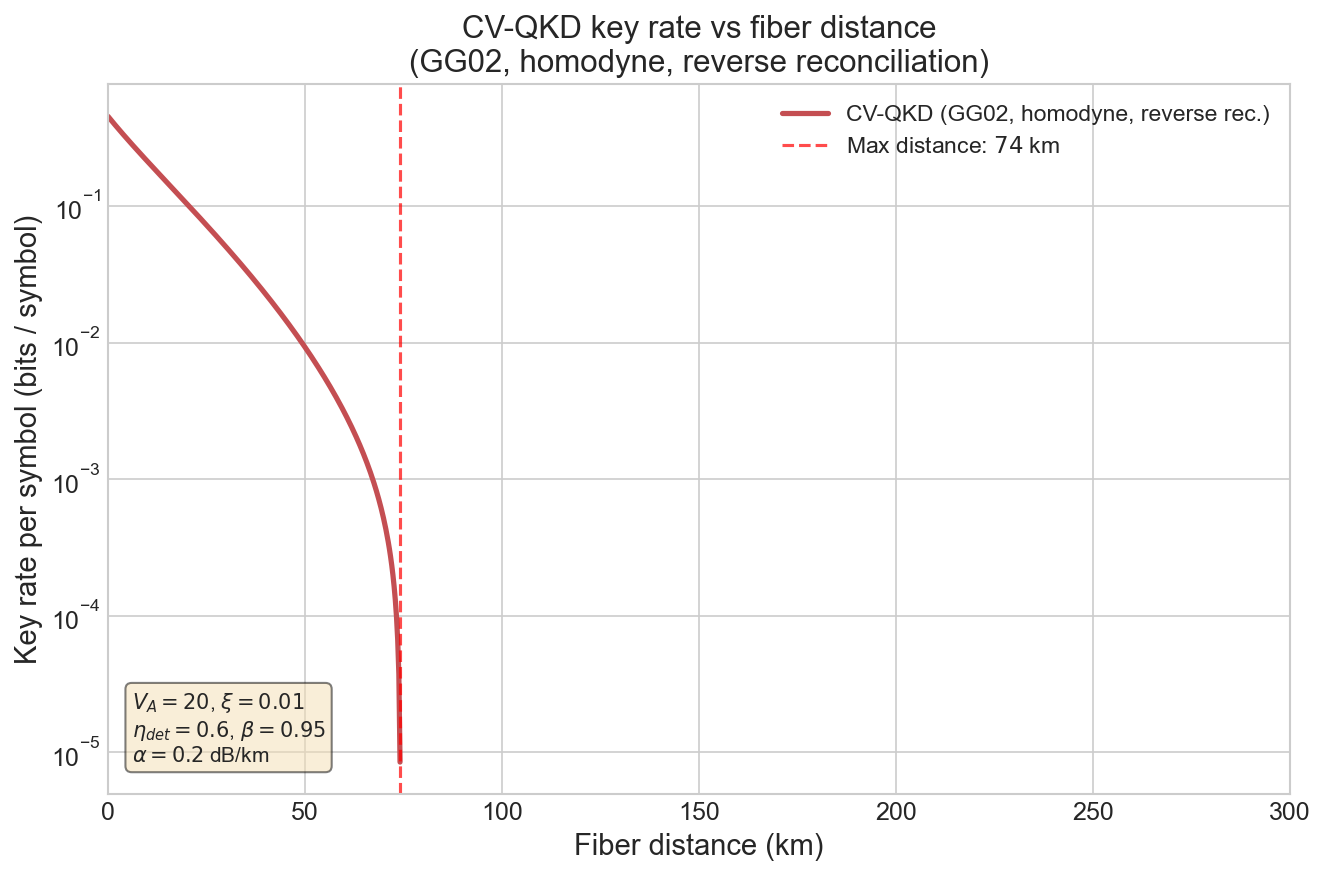

CV-QKD max secure distance (default params): 74.1 km


In [3]:
rates_cv = cvqkd_key_rate(L)
positive = rates_cv > 0
if positive.all():
    L_max_cv = float(L[-1])
else:
    cutoff_idx = int(np.where(~positive)[0][0])
    L_max_cv = float(L[cutoff_idx - 1])

fig, ax = plt.subplots(figsize=(9, 6))
semilogy_positive(
    ax, L, rates_cv, '-', color='#C44E52', linewidth=2.5,
    label='CV-QKD (GG02, homodyne, reverse rec.)',
)
ax.axvline(L_max_cv, color='red', linestyle='--', alpha=0.7,
           label=fr'Max distance: ${L_max_cv:.0f}$ km')
ax.set_xlabel('Fiber distance (km)', fontsize=14)
ax.set_ylabel('Key rate per symbol (bits / symbol)', fontsize=14)
ax.set_title('CV-QKD key rate vs fiber distance\n'
             '(GG02, homodyne, reverse reconciliation)', fontsize=15)
ax.legend(fontsize=11, loc='upper right')
param_text = (
    r'$V_A = 20$, $\xi = 0.01$' + '\n'
    r'$\eta_{det} = 0.6$, $\beta = 0.95$' + '\n'
    r'$\alpha = 0.2$ dB/km'
)
ax.text(0.02, 0.04, param_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlim(0, 300)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cvqkd_key_rate_distance.png', dpi=300,
            bbox_inches='tight')
plt.show()

print(f'CV-QKD max secure distance (default params): {L_max_cv:.1f} km')


## 3. Excess noise sensitivity

$\xi$ is the input-referred excess noise. Even small values shave off significant range &mdash; CV-QKD is much more noise-sensitive than BB84 is to dark counts. The figure below compares four settings at fixed $\beta = 0.95$, $V_A = 20$.

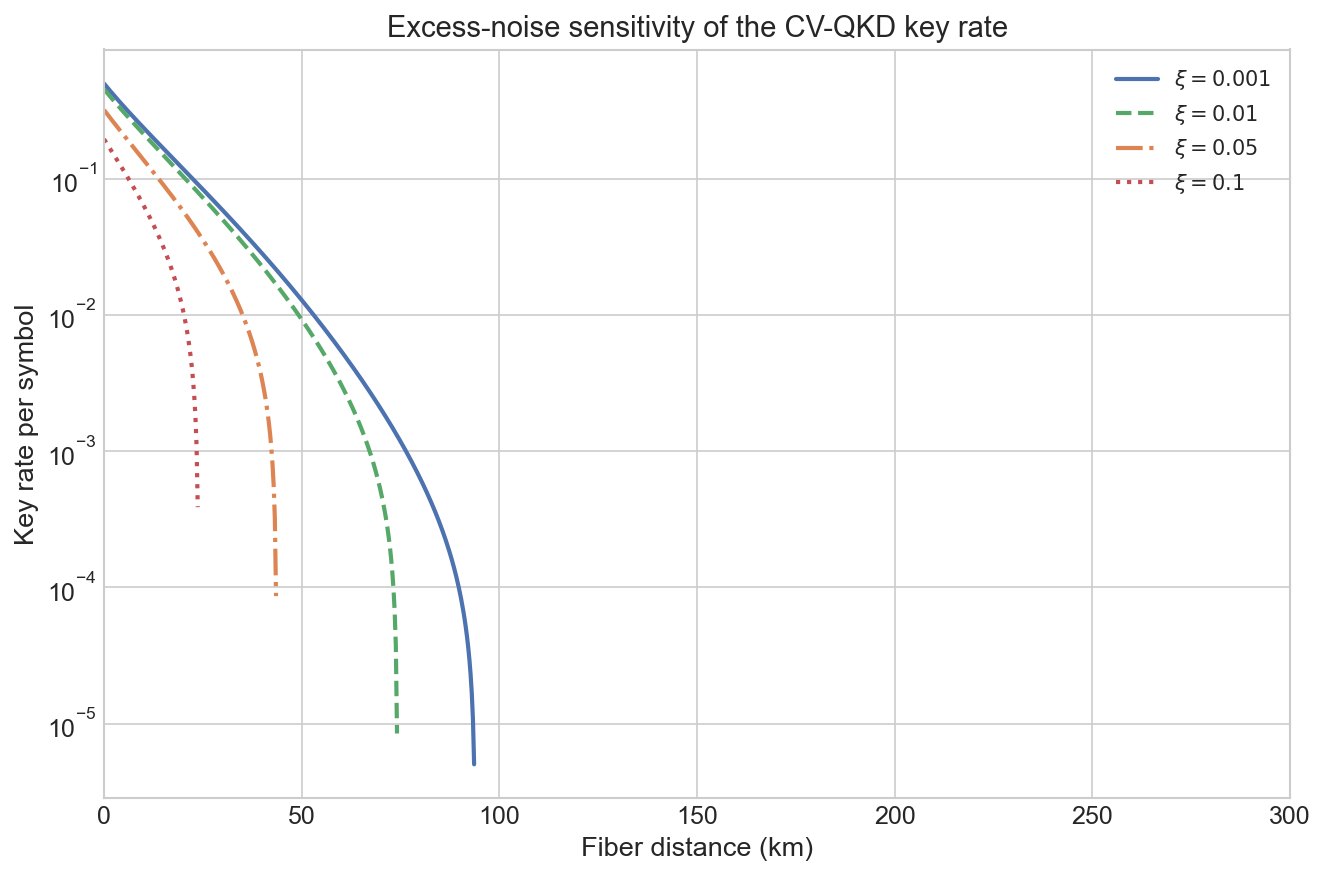

xi      max distance (km)
  0.001             93.6
  0.010             74.1
  0.050             43.5
  0.100             23.7


In [4]:
xi_values = [0.001, 0.01, 0.05, 0.10]
xi_styles = [('-', '#4C72B0'), ('--', '#55A868'),
             ('-.', '#DD8452'), (':', '#C44E52')]

fig, ax = plt.subplots(figsize=(9, 6))
summary = []
for xi_val, (ls, color) in zip(xi_values, xi_styles):
    r = cvqkd_key_rate(L, xi=xi_val)
    semilogy_positive(ax, L, r, ls, color=color, linewidth=2,
                      label=fr'$\xi = {xi_val}$')
    if (r > 0).any():
        L_max = float(L[r > 0].max())
    else:
        L_max = 0.0
    summary.append((xi_val, L_max))
ax.set_xlabel('Fiber distance (km)', fontsize=13)
ax.set_ylabel('Key rate per symbol', fontsize=13)
ax.set_title('Excess-noise sensitivity of the CV-QKD key rate',
             fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(0, 300)
plt.tight_layout()
plt.savefig(FIG_DIR / 'excess_noise_effect.png', dpi=300,
            bbox_inches='tight')
plt.show()

print('xi      max distance (km)')
for xi_val, L_max in summary:
    print(f'{xi_val:>7.3f} {L_max:>16.1f}')


## 4. Reconciliation-efficiency sensitivity

$\beta$ multiplies $I(A:B)$ but **not** the Holevo bound. Lowering $\beta$ therefore shifts the cutoff inwards: the rate becomes negative sooner.